In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.distributions.empirical_distribution import ECDF
import scipy.stats as stats

In [2]:
# Параметры варианта 10
m = 11
sigma = 1

# Генерируем точки для аналитической таблицы
x_points = np.array([8, 9, 10, 11, 12, 13, 14])
f_x = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x_points - m)**2) / (2 * sigma**2))

# Оформляем в красивую таблицу для отчета
df_analyt = pd.DataFrame({
    'x (Аргумент)': x_points,
    'f(x) (Плотность)': np.round(f_x, 4)
})

print("Значения для переноса на бумагу:")
print(df_analyt.to_string(index=False))

Значения для переноса на бумагу:
 x (Аргумент)  f(x) (Плотность)
            8            0.0044
            9            0.0540
           10            0.2420
           11            0.3989
           12            0.2420
           13            0.0540
           14            0.0044


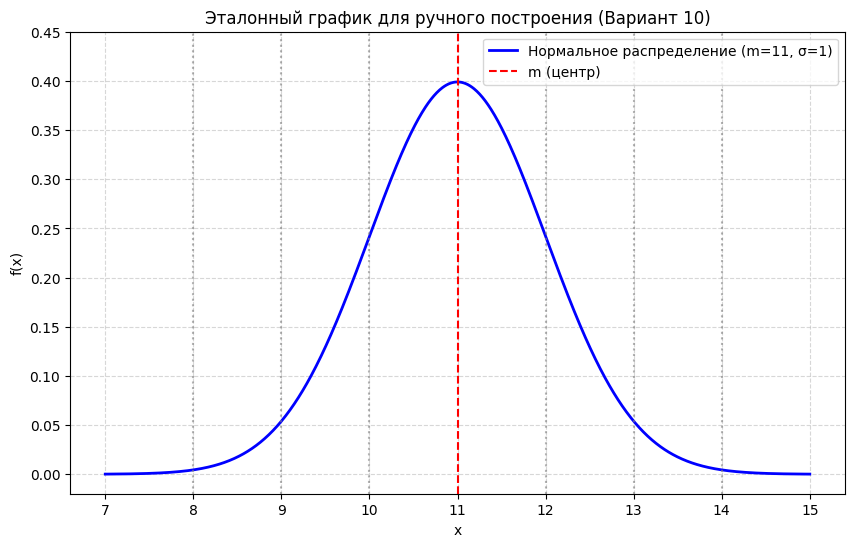

In [3]:
# Параметры варианта 10
m = 11
sigma = 1

# Генерируем данные
x = np.linspace(m - 4*sigma, m + 4*sigma, 1000)
y = norm.pdf(x, m, sigma)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', lw=2, label=f'Нормальное распределение (m={m}, σ={sigma})')

# Отмечаем линии математического ожидания и сигм
plt.axvline(m, color='r', linestyle='--', label='m (центр)')
for i in range(1, 4):
    plt.axvline(m + i*sigma, color='gray', linestyle=':', alpha=0.6)
    plt.axvline(m - i*sigma, color='gray', linestyle=':', alpha=0.6)

# Оформление для удобства переноса в тетрадь
plt.xticks(np.arange(m-4, m+5, 1))
plt.yticks(np.arange(0, 0.5, 0.05))
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.title(f"Эталонный график для ручного построения (Вариант 10)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

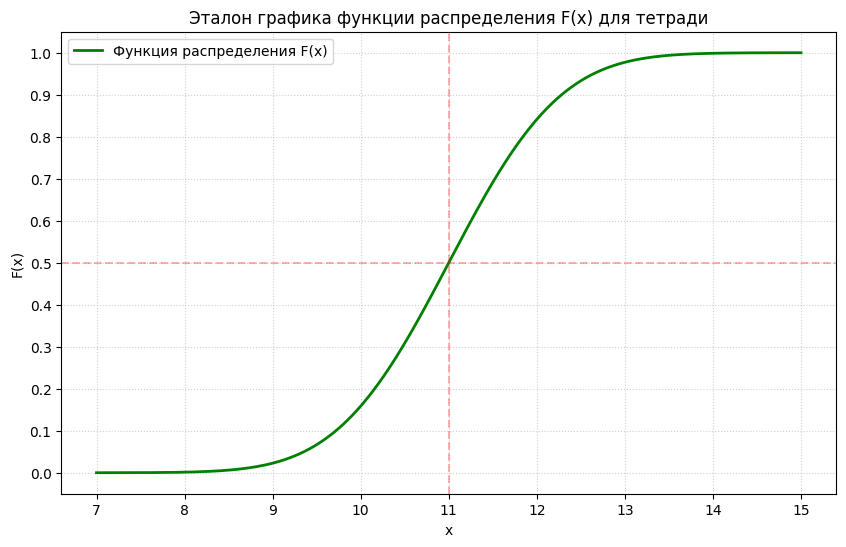

In [4]:
m = 11
sigma = 1

x = np.linspace(7, 15, 1000)
y_cdf = norm.cdf(x, m, sigma) # Cumulative Distribution Function

plt.figure(figsize=(10, 6))
plt.plot(x, y_cdf, 'g-', lw=2, label=f'Функция распределения F(x)')

# Сетка для удобства рисования
plt.xticks(np.arange(7, 16, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.axhline(0.5, color='r', linestyle='--', alpha=0.3) # Линия 0.5
plt.axvline(11, color='r', linestyle='--', alpha=0.3) # Линия m

plt.title("Эталон графика функции распределения F(x) для тетради")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend()
plt.show()

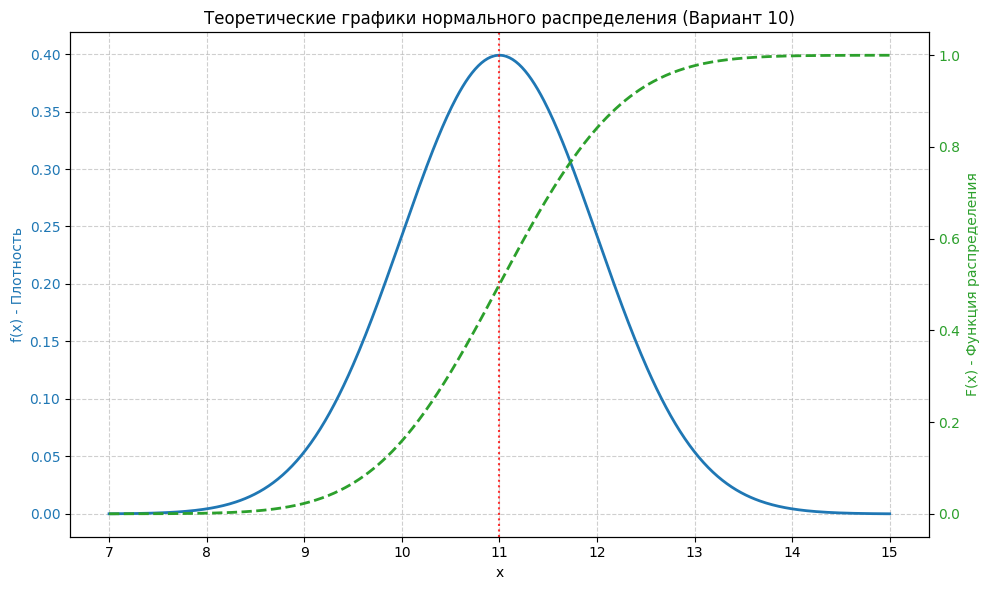

In [5]:
# Параметры варианта 10
m = 11
sigma = 1

# Создаем сетку значений
x = np.linspace(m - 4*sigma, m + 4*sigma, 500)

# Вычисляем теоретическую плотность и функцию распределения
pdf_theory = norm.pdf(x, m, sigma)
cdf_theory = norm.cdf(x, m, sigma)

# Визуализация
fig, ax1 = plt.subplots(figsize=(10, 6))

# Рисуем плотность вероятности (левая ось)
color = 'tab:blue'
ax1.set_xlabel('x')
ax1.set_ylabel('f(x) - Плотность', color=color)
ax1.plot(x, pdf_theory, color=color, lw=2, label='Плотность f(x)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Создаем вторую ось для функции распределения (правая ось)
ax2 = ax1.twinx() 
color = 'tab:green'
ax2.set_ylabel('F(x) - Функция распределения', color=color)
ax2.plot(x, cdf_theory, color=color, lw=2, linestyle='--', label='Распределение F(x)')
ax2.tick_params(axis='y', labelcolor=color)

# Добавляем вертикальную линию мат. ожидания
ax1.axvline(m, color='red', linestyle=':', alpha=0.8, label=f'm={m}')

plt.title('Теоретические графики нормального распределения (Вариант 10)')
fig.tight_layout()
plt.show()

In [6]:
# Параметры варианта 10
m = 11
sigma = 1
volumes = [1000, 5000, 10000]

# Словарь для хранения всех наших выборок
data_samples = {}

# --- МЕТОД 1: Центральная предельная теорема (Суммирование 12 чисел) ---
def generate_clt(n, m, sigma):
    samples = []
    for _ in range(n):
        # Суммируем 12 случайных чисел от 0 до 1
        s = sum(np.random.uniform(0, 1, 12))
        # Стандартизируем (вычитаем 6, т.к. среднее суммы 12 равномерных = 6)
        # и приводим к нашему m и sigma
        z = (s - 6) * sigma + m
        samples.append(z)
    return np.array(samples)

# --- МЕТОД 2: Преобразование Бокса-Мюллера ---
def generate_box_muller(n, m, sigma):
    # Генерируем парами, поэтому берем n/2
    u1 = np.random.uniform(0, 1, int(np.ceil(n/2)))
    u2 = np.random.uniform(0, 1, int(np.ceil(n/2)))
    
    z0 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
    # Приводим к параметрам варианта
    return (z0[:n] * sigma) + m

# --- МЕТОД 3: Полярный метод (Марсальи) ---
def generate_marsaglia(n, m, sigma):
    samples = []
    while len(samples) < n:
        u, v = np.random.uniform(-1, 1, 2)
        s = u**2 + v**2
        if 0 < s < 1:
            z0 = u * np.sqrt(-2 * np.log(s) / s)
            samples.append(z0 * sigma + m)
    return np.array(samples[:n])

# --- ГЕНЕРАЦИЯ ВСЕХ НАБОРОВ ---
methods = {
    "CLT": generate_clt,
    "Box-Muller": generate_box_muller,
    "Marsaglia": generate_marsaglia,
    "Built-in": lambda n, m, sigma: np.random.normal(m, sigma, n)
}

for method_name, func in methods.items():
    for v in volumes:
        key = f"{method_name}_{v}"
        data_samples[key] = func(v, m, sigma)
        print(f"Сгенерирована выборка: {key}")

print("\nВсе 12 наборов данных готовы к анализу!")

Сгенерирована выборка: CLT_1000
Сгенерирована выборка: CLT_5000
Сгенерирована выборка: CLT_10000
Сгенерирована выборка: Box-Muller_1000
Сгенерирована выборка: Box-Muller_5000
Сгенерирована выборка: Box-Muller_10000
Сгенерирована выборка: Marsaglia_1000
Сгенерирована выборка: Marsaglia_5000
Сгенерирована выборка: Marsaglia_10000
Сгенерирована выборка: Built-in_1000
Сгенерирована выборка: Built-in_5000
Сгенерирована выборка: Built-in_10000

Все 12 наборов данных готовы к анализу!


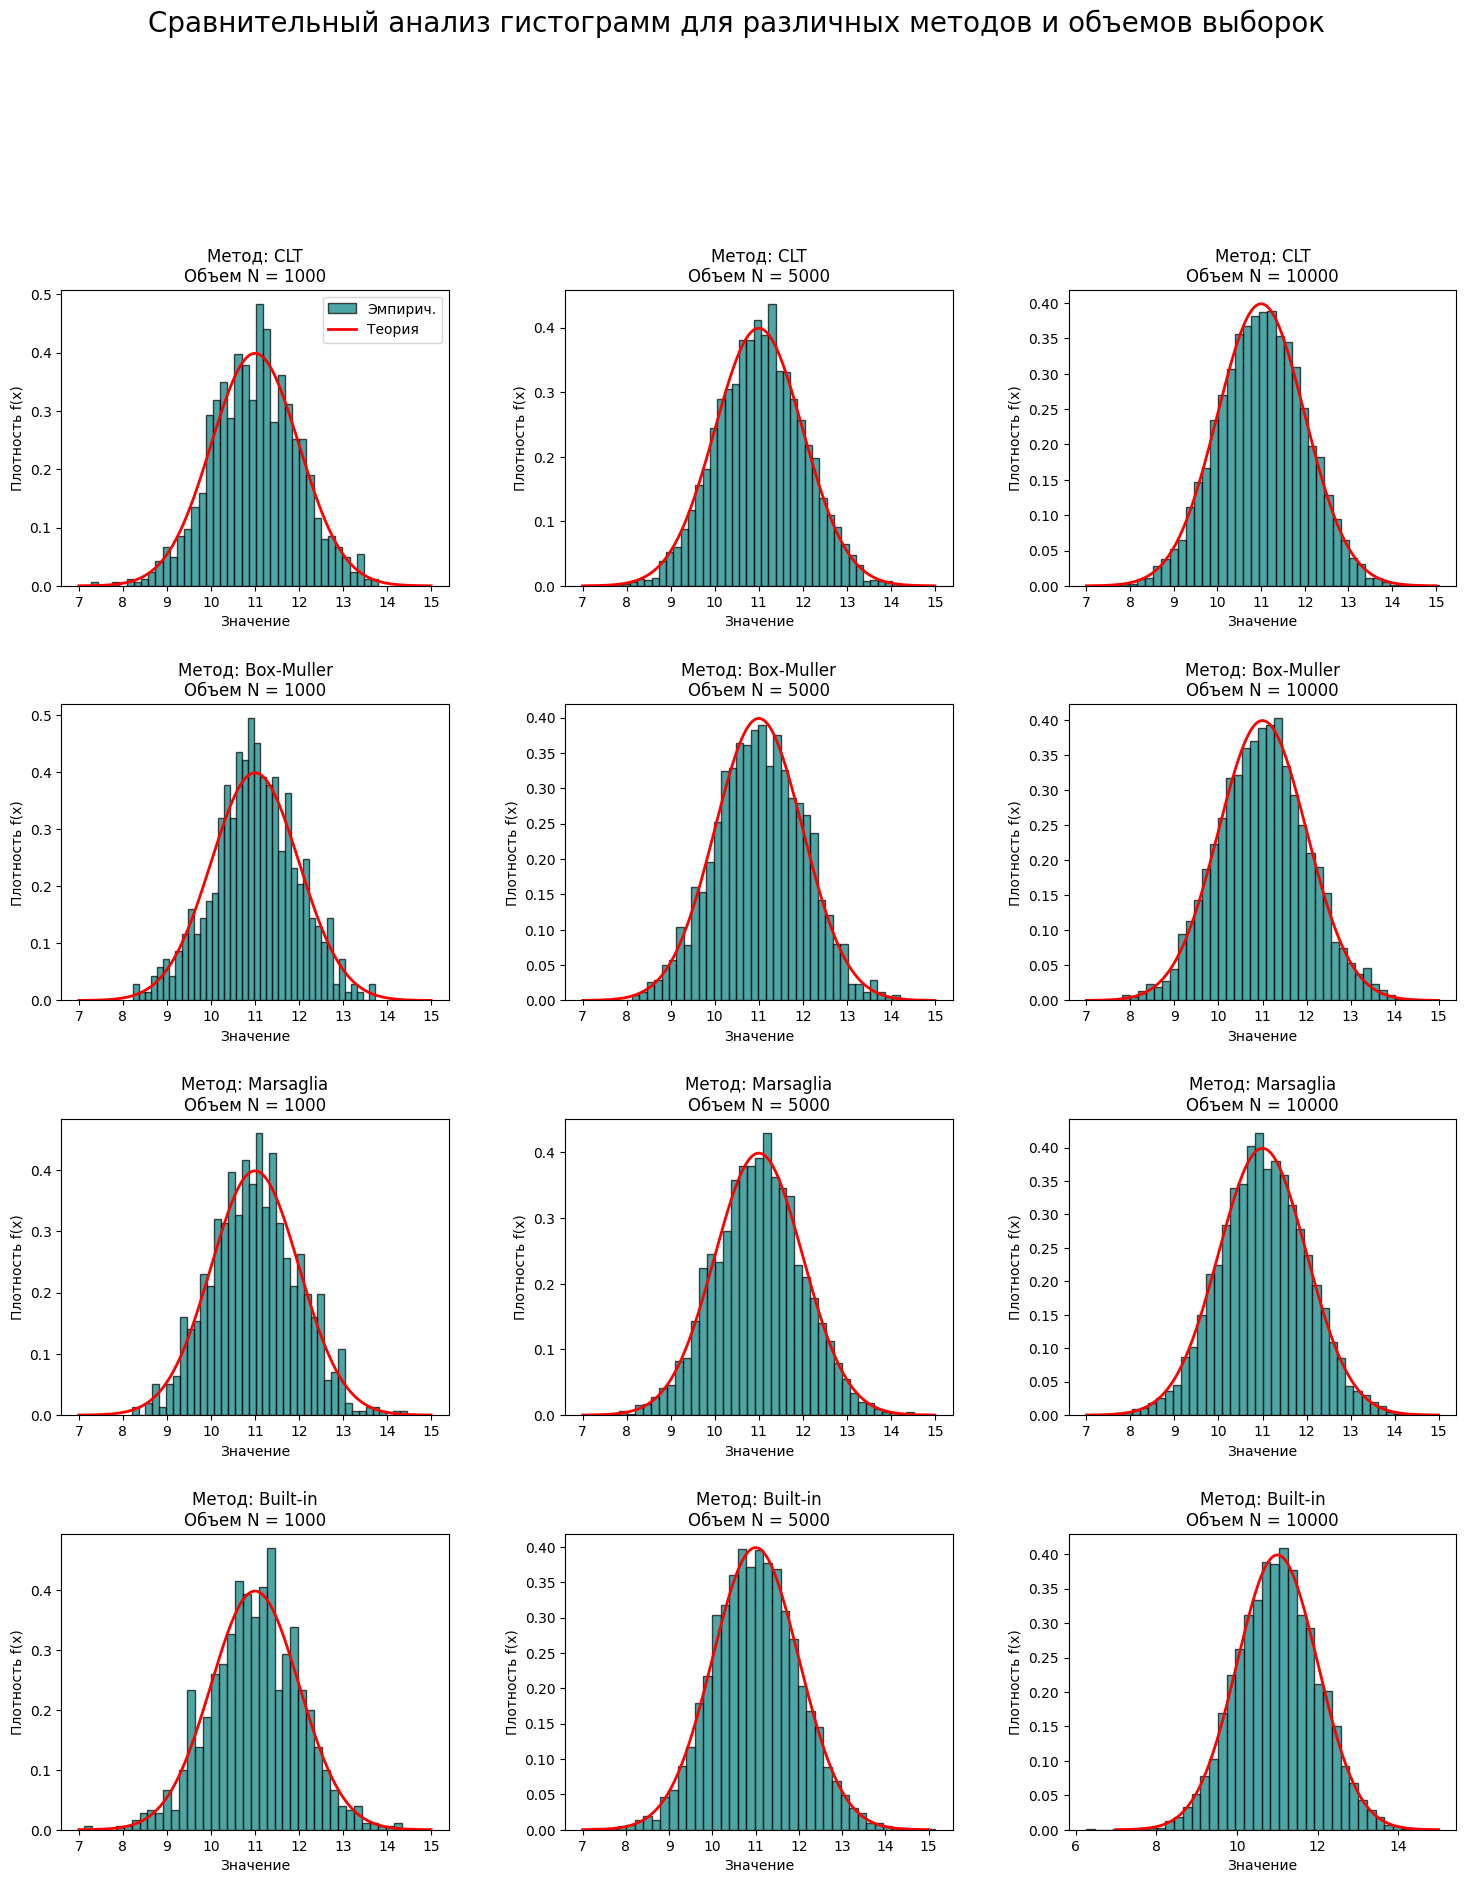

In [7]:
# Параметры варианта 10
m = 11
sigma = 1

methods_list = ["CLT", "Box-Muller", "Marsaglia", "Built-in"]
volumes = [1000, 5000, 10000]

# Создаем сетку графиков 4x3
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Точки для теоретической кривой
x_theory = np.linspace(m - 4*sigma, m + 4*sigma, 200)
y_theory = norm.pdf(x_theory, m, sigma)

for i, method in enumerate(methods_list):
    for j, v in enumerate(volumes):
        key = f"{method}_{v}"
        data = data_samples[key]
        
        ax = axes[i, j]
        
        # Строим гистограмму (density=True превращает частоты в плотность)
        ax.hist(data, bins=40, density=True, color='teal', alpha=0.7, edgecolor='black', label='Эмпирич.')
        
        # Накладываем теорию
        ax.plot(x_theory, y_theory, 'r-', lw=2, label='Теория')
        
        ax.set_title(f"Метод: {method}\nОбъем N = {v}")
        ax.set_xlabel("Значение")
        ax.set_ylabel("Плотность f(x)")
        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Сравнительный анализ гистограмм для различных методов и объемов выборок", fontsize=20, y=1.02)
plt.show()

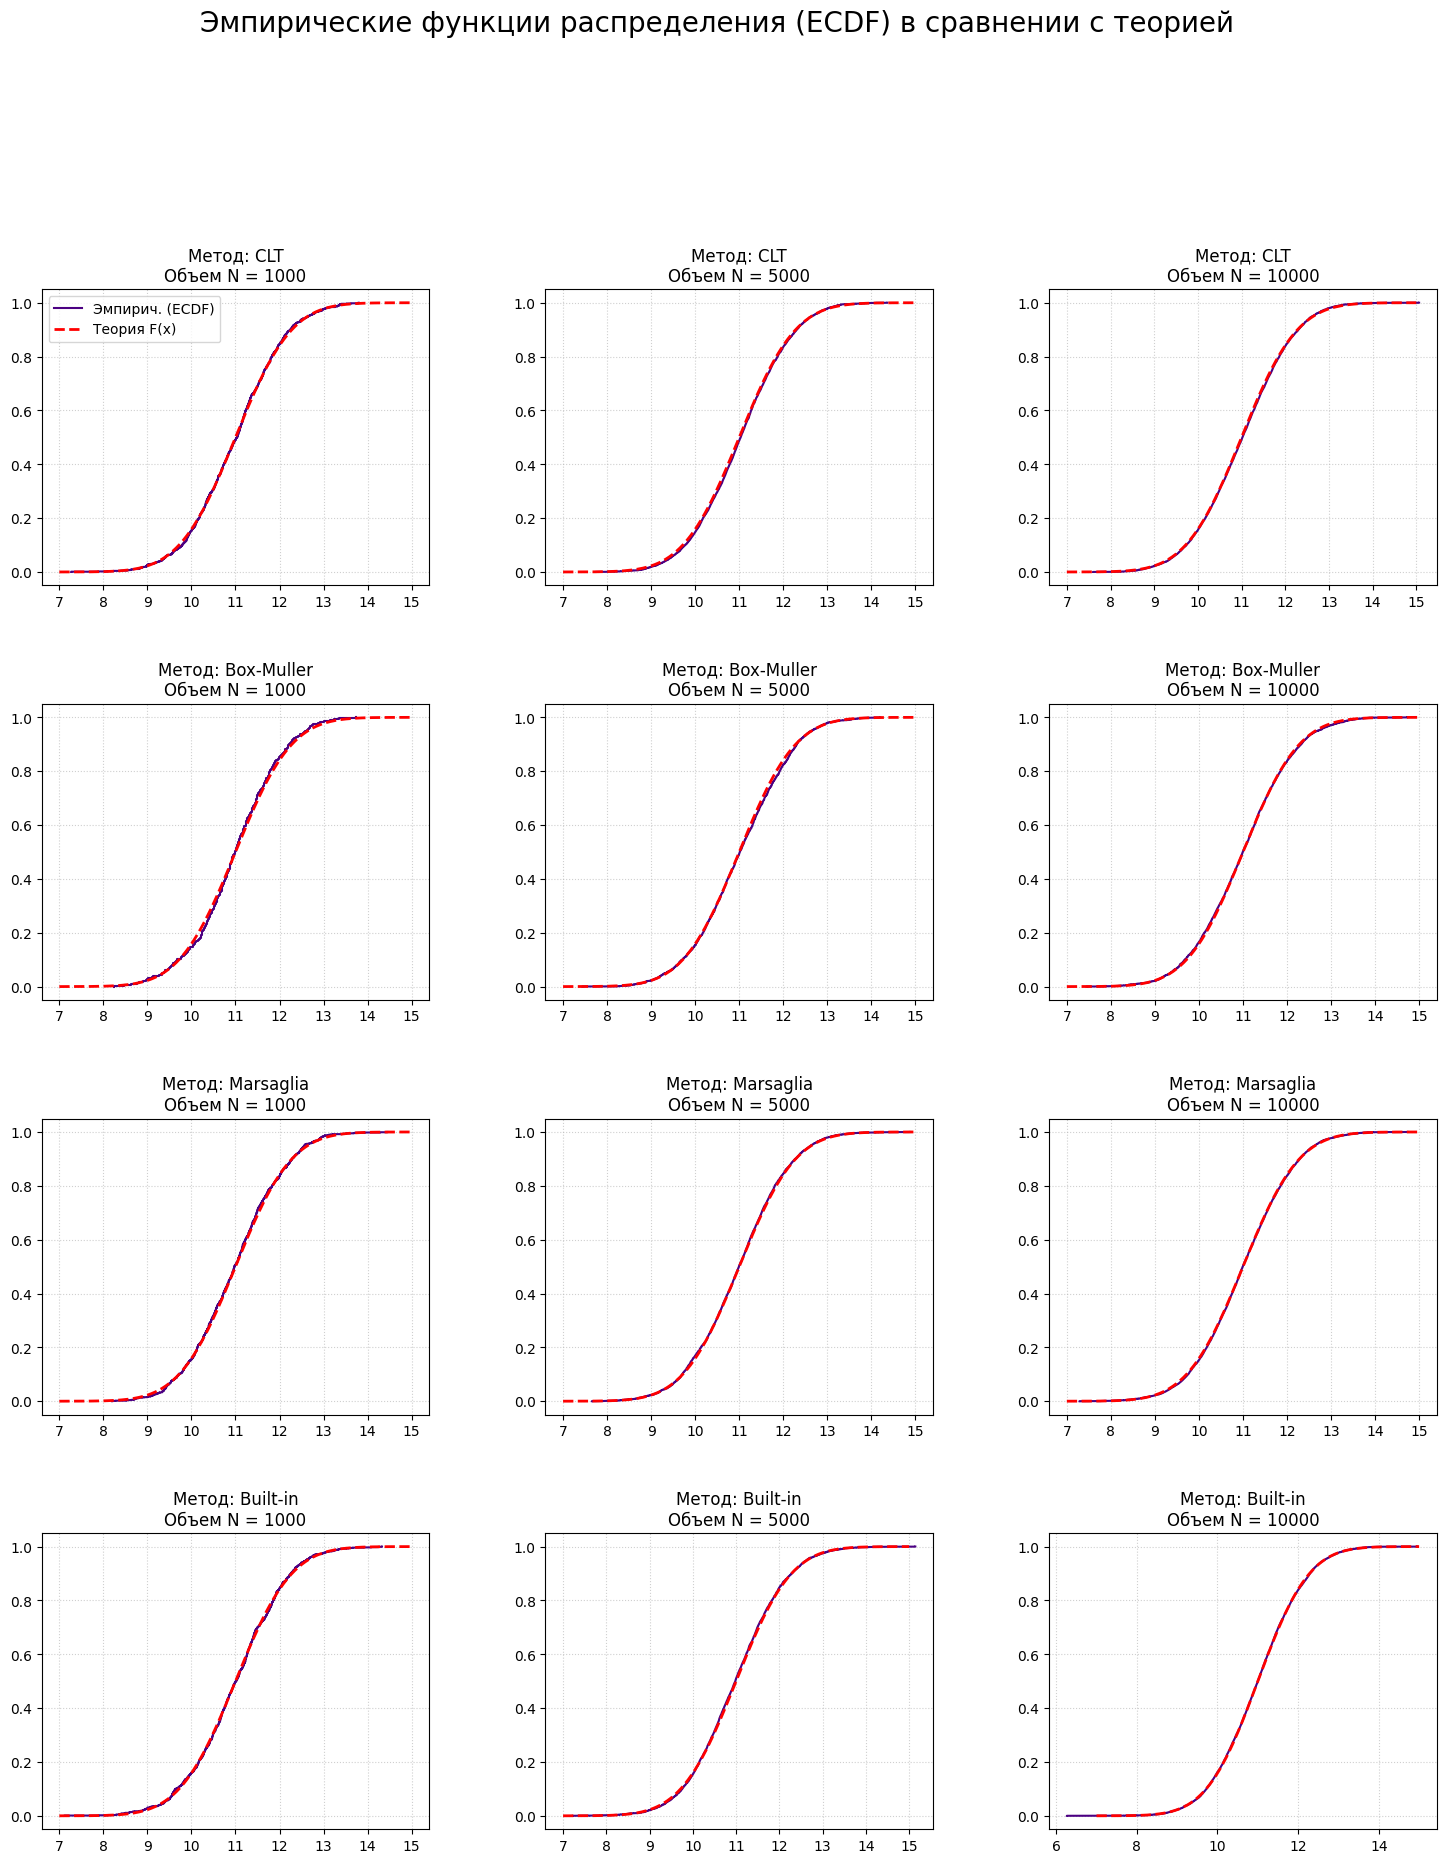

In [8]:
# Создаем сетку графиков 4x3
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Точки для теоретической CDF
x_theory = np.linspace(m - 4*sigma, m + 4*sigma, 200)
y_cdf_theory = norm.cdf(x_theory, m, sigma)

for i, method in enumerate(methods_list):
    for j, v in enumerate(volumes):
        key = f"{method}_{v}"
        data = data_samples[key]
        
        ax = axes[i, j]
        
        # Вычисляем ECDF
        ecdf = ECDF(data)
        
        # Строим эмпирическую функцию
        ax.step(ecdf.x, ecdf.y, color='indigo', label='Эмпирич. (ECDF)', where='post')
        
        # Накладываем теоретическую F(x)
        ax.plot(x_theory, y_cdf_theory, 'r--', lw=2, label='Теория F(x)')
        
        ax.set_title(f"Метод: {method}\nОбъем N = {v}")
        ax.grid(True, linestyle=':', alpha=0.6)
        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Эмпирические функции распределения (ECDF) в сравнении с теорией", fontsize=20, y=1.02)
plt.show()

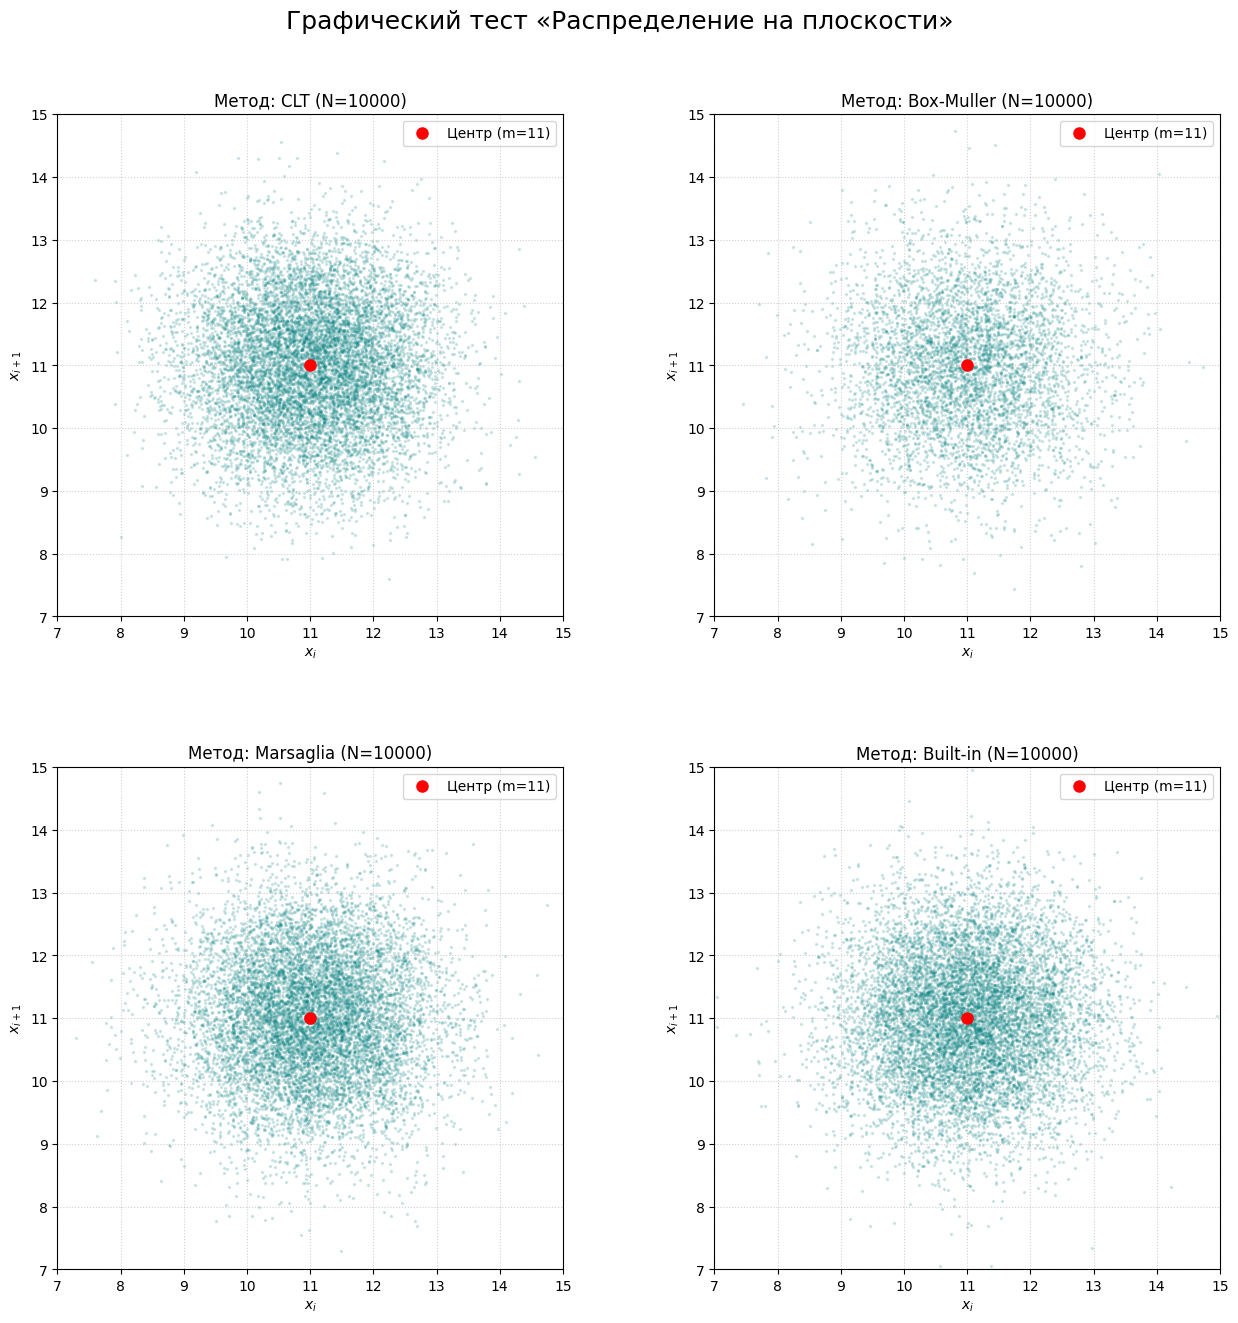

In [9]:
# Создаем сетку графиков 2x2 для четырех методов (для N=10000)
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

target_v = 10000
methods_list = ["CLT", "Box-Muller", "Marsaglia", "Built-in"]

for i, method in enumerate(methods_list):
    key = f"{method}_{target_v}"
    data = data_samples[key]
    
    # Формируем пары (x_i, x_{i+1})
    x_coords = data[:-1]
    y_coords = data[1:]
    
    ax = axes[i // 2, i % 2]
    
    # Рисуем точки с высокой прозрачностью, чтобы видеть плотность
    ax.scatter(x_coords, y_coords, s=2, alpha=0.15, color='teal')
    
    # Отмечаем центр (m, m)
    ax.plot(m, m, 'ro', markersize=8, label=f'Центр (m={m})')
    
    ax.set_title(f"Метод: {method} (N={target_v})")
    ax.set_xlabel("$x_i$")
    ax.set_ylabel("$x_{i+1}$")
    ax.set_xlim(m-4*sigma, m+4*sigma)
    ax.set_ylim(m-4*sigma, m+4*sigma)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

plt.suptitle("Графический тест «Распределение на плоскости»", fontsize=18, y=0.95)
plt.show()

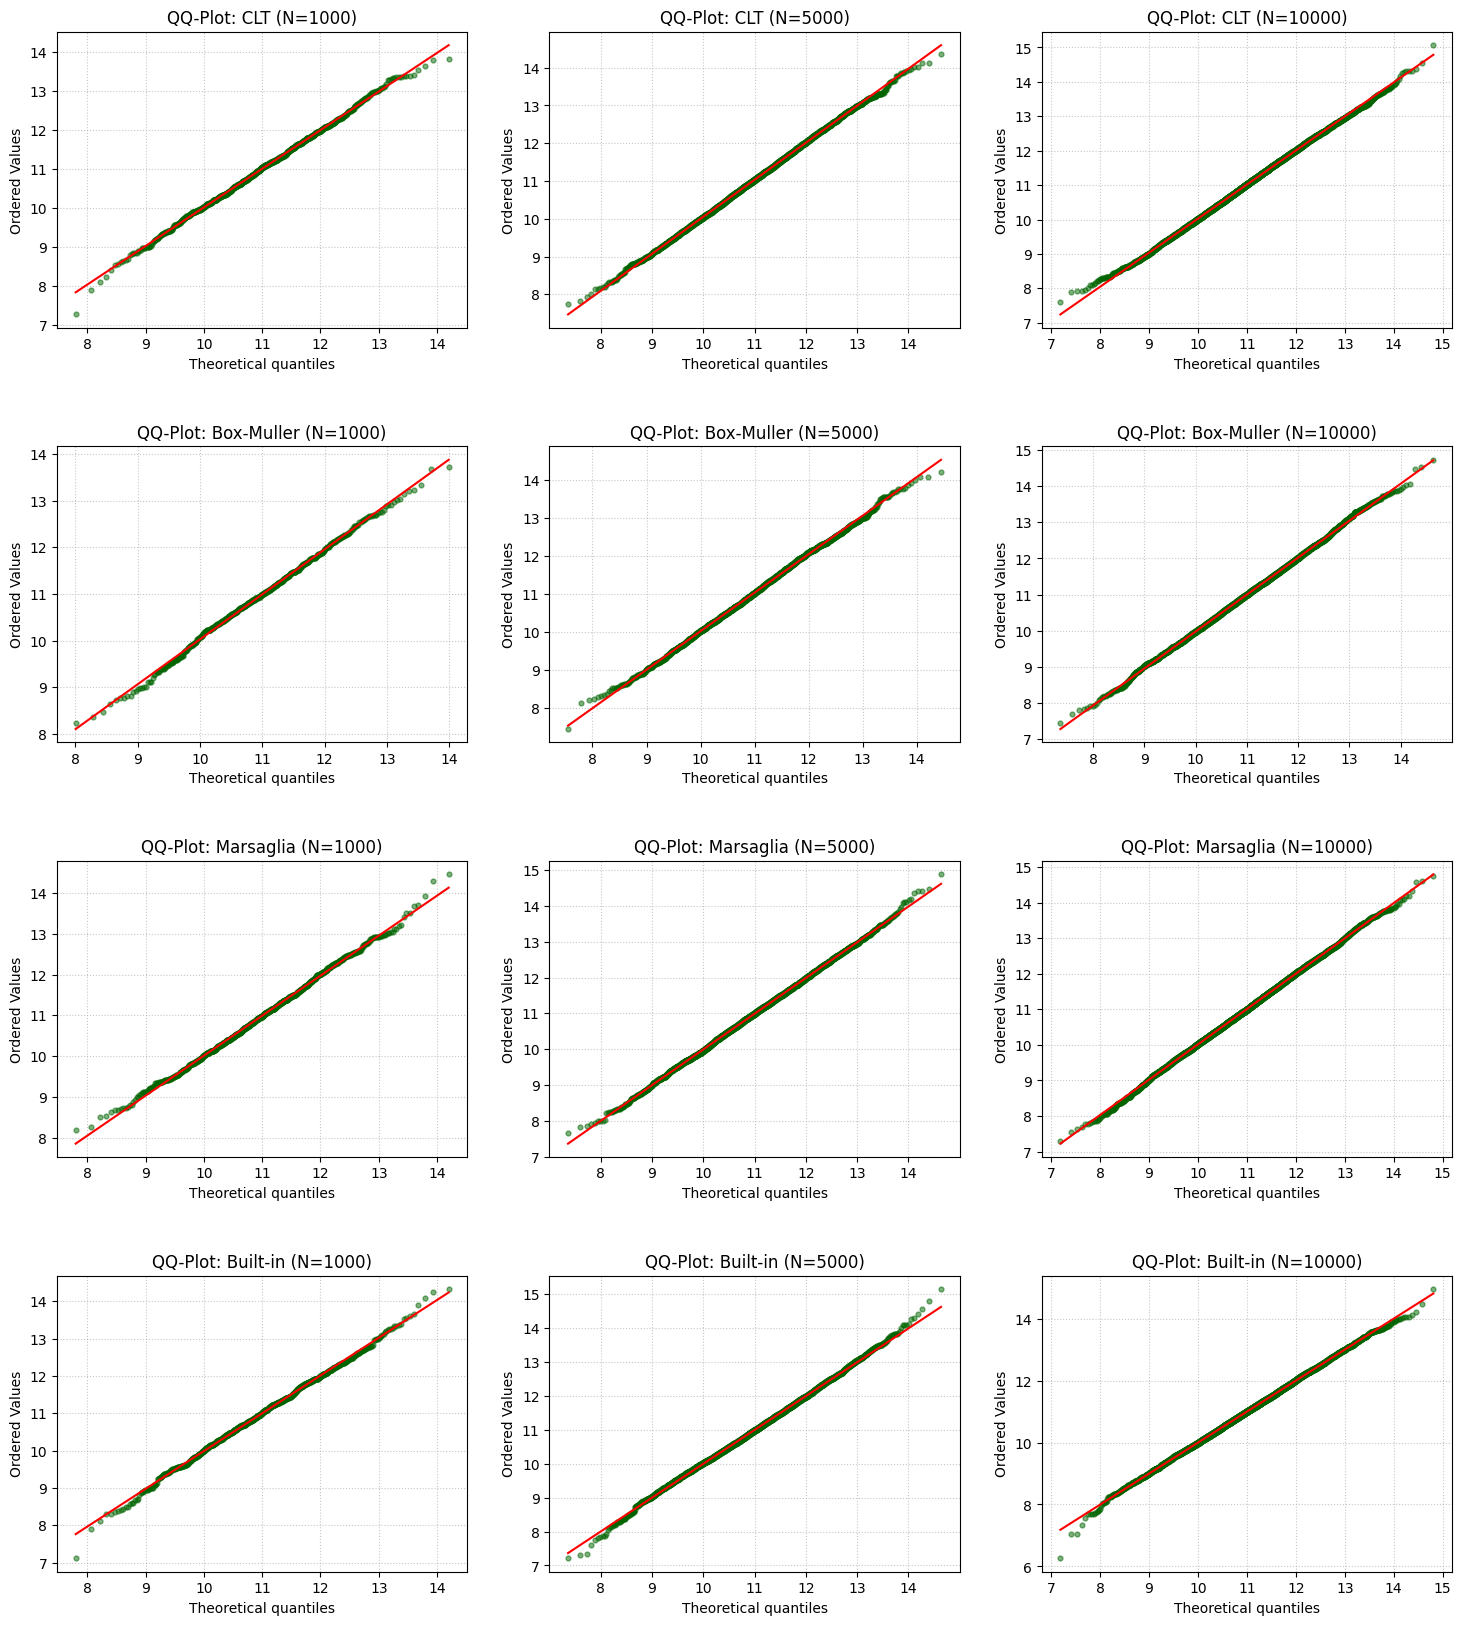

In [10]:
import scipy.stats as stats

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
plt.subplots_adjust(hspace=0.4)

for i, method in enumerate(methods_list):
    for j, v in enumerate(volumes):
        key = f"{method}_{v}"
        data = data_samples[key]
        ax = axes[i, j]
        # Проверка на нормальность относительно параметров m и sigma
        stats.probplot(data, dist="norm", sparams=(m, sigma), plot=ax)
        ax.set_title(f"QQ-Plot: {method} (N={v})")
        line_points = ax.get_lines()[0]
        line_points.set_markerfacecolor('darkgreen') 
        line_points.set_markeredgecolor('darkgreen') 
        line_points.set_markersize(3.5)                
        line_points.set_alpha(0.5)                   
        ax.grid(True, linestyle=':', alpha=0.7)

plt.show()

In [11]:
stats_list = []

for method_name in methods_list:
    for v in volumes:
        key = f"{method_name}_{v}"
        data = data_samples[key]
        
        # Расчет характеристик
        m_emp = np.mean(data)          # Эмпирическое среднее
        d_emp = np.var(data)           # Эмпирическая дисперсия
        s_emp = np.std(data)           # Эмпирическое СКО
        
        # Расчет отклонения среднего от теоретического (m=11) в процентах
        error_m = abs(m_emp - m) / m * 100
        
        stats_list.append({
            "Метод": method_name,
            "N": v,
            "Мат. ожидание": round(m_emp, 4),
            "Дисперсия": round(d_emp, 4),
            "СКО": round(s_emp, 4),
            "Погрешность M (%)": round(error_m, 3)
        })

# Перевод списка в датафрейм
df_stats = pd.DataFrame(stats_list)
print(df_stats.to_string(index=False))

     Метод     N  Мат. ожидание  Дисперсия    СКО  Погрешность M (%)
       CLT  1000        10.9992     0.9754 0.9876              0.007
       CLT  5000        11.0308     0.9594 0.9795              0.280
       CLT 10000        11.0150     0.9796 0.9897              0.136
Box-Muller  1000        10.9912     0.9231 0.9608              0.080
Box-Muller  5000        11.0237     1.0238 1.0118              0.216
Box-Muller 10000        10.9991     1.0467 1.0231              0.009
 Marsaglia  1000        10.9926     0.9561 0.9778              0.067
 Marsaglia  5000        10.9888     0.9955 0.9977              0.102
 Marsaglia 10000        11.0097     0.9880 0.9940              0.088
  Built-in  1000        10.9989     1.0209 1.0104              0.010
  Built-in  5000        10.9925     0.9945 0.9972              0.068
  Built-in 10000        10.9986     1.0020 1.0010              0.013


=== РЕЗУЛЬТАТЫ ЦПТ (Экспоненциальное распределение) ===
Объем выборки (N): 10000
Слагаемых (n): 50
Мат. ожидание: 10.9952 (Погрешность: 0.044%)
Дисперсия: 1.0210
СКО: 1.0104


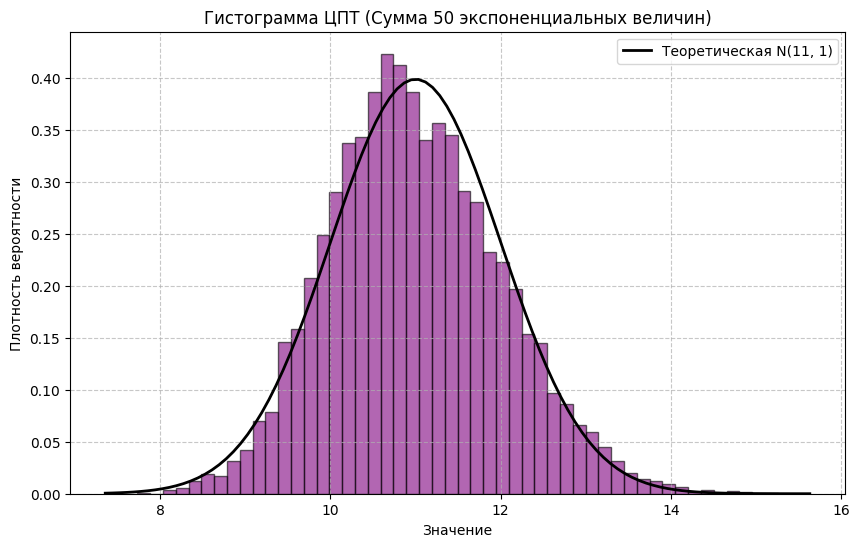

In [12]:
def generate_clt_exponential(n_samples=10000, n_summands=50, target_m=11, target_sigma=1):
    # Параметры базового экспоненциального распределения
    lam = 1.0
    mu = 1.0 / lam
    sigma_base = 1.0 / lam
    
    # 1. Генерируем матрицу (10000 строк x 50 столбцов) из экспоненциального распределения
    # Используем формулу обратной функции: -ln(1-u)/lambda
    u = np.random.uniform(0, 1, size=(n_samples, n_summands))
    exp_data = -np.log(1 - u) / lam
    
    # 2. Считаем сумму по строкам (сумма n_summands величин)
    sums = np.sum(exp_data, axis=1)
    
    # 3. Нормируем сумму по формуле ЦПТ, чтобы получить N(0, 1)
    # Z = (S - n*mu) / (sigma_base * sqrt(n))
    z = (sums - n_summands * mu) / (sigma_base * np.sqrt(n_summands))
    
    # 4. Сдвигаем к нашим целевым параметрам N(11, 1)
    result = z * target_sigma + target_m
    
    # --- СТАТИСТИКА ---
    calc_m = np.mean(result)
    calc_var = np.var(result)
    calc_std = np.std(result)
    err_m = abs(calc_m - target_m) / target_m * 100
    
    print("=== РЕЗУЛЬТАТЫ ЦПТ (Экспоненциальное распределение) ===")
    print(f"Объем выборки (N): {n_samples}")
    print(f"Слагаемых (n): {n_summands}")
    print(f"Мат. ожидание: {calc_m:.4f} (Погрешность: {err_m:.3f}%)")
    print(f"Дисперсия: {calc_var:.4f}")
    print(f"СКО: {calc_std:.4f}")
    
    # --- ГРАФИК ---
    plt.figure(figsize=(10, 6))
    count, bins, ignored = plt.hist(result, bins=50, density=True, alpha=0.6, color='purple', edgecolor='black')
    
    # Теоретическая кривая
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, target_m, target_sigma)
    plt.plot(x, p, 'k', linewidth=2, label='Теоретическая N(11, 1)')
    
    plt.title(f'Гистограмма ЦПТ (Сумма {n_summands} экспоненциальных величин)')
    plt.xlabel('Значение')
    plt.ylabel('Плотность вероятности')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Запускаем генерацию
generate_clt_exponential()